# Jane Street July 2026 puzzle — Knight Moves 7 (my solution)

So this month's puzzle is an 8×8 board cut up into 13 pieces (the 12 pentominoes plus a 2×2 square). Every piece gets one "tower" — basically an extra cube stacked on one of its squares, so that square is height 2 and everything else is height 1.

A knight starts at the bottom-left corner with a score of 0 and hops around until it has stepped on all 13 towers. It can never land on the same square twice. Moves are 3D: it shifts 0 in one direction, 1 in another, and 2 in the third. That works out to:

- **flat move** (same height): a normal knight move, and the score goes **up by N** on move number N
- **going up** (height 1 → 2): the knight slides (0, ±2) or (±2, 0) on the board, and the score gets **multiplied by N**
- **going down** (height 2 → 1): same slide pattern, score gets **divided by N** — but only allowed if N divides the score cleanly

(Jumping up or down by 2 can't happen since heights are only ever 1 or 2.)

The knight wrote its score every 3 moves up to move 18, then every K moves after that for some unknown K > 3. Those written scores are the numbers on the grid. The job: figure out the whole path, fill in scores for every visited square, then for each **unvisited** square add up the scores sitting next to it (up/down/left/right), and sum all of that. That total is the answer.

Here's how I did it:

1. Set up the board (regions + the given numbers).
2. Show that just playing with the score math forces basically everything — the checkpoint values, the move types, even K = 7.
3. Run a brute-force search over the actual board to nail down the one path that works.
4. Double-check everything from scratch and compute the answer.


## 1. Setting up the board

I pulled the regions straight out of the puzzle image with some code (measured which grid lines were drawn thick vs thin, then grouped cells together). Nice sanity check: the 13 regions came out as exactly the 12 different pentominoes (I, V, U, P, Z, N, Y, F, L, T, X, W) plus the 2×2 square — so the extraction is almost certainly right. I'm using `(row, col)` coordinates with row 0 at the top, and the knight starts at `(7, 0)`.

In [1]:
REG = ["AAAAABBB",
       "CCCDDEEB",
       "CFCDDDEB",
       "GFFHHIEE",
       "GGFHHIIJ",
       "GKFLIIMJ",
       "GKLLLMMJ",
       "KKKLMMJJ"]

region = {}
cells_of = {}
for r in range(8):
    for c in range(8):
        g = REG[r][c]
        region[(r, c)] = g
        cells_of.setdefault(g, []).append((r, c))

# pentomino identity of each region (sanity documentation)
PENTOMINO = {'A':'I','B':'V','C':'U','D':'P','E':'Z','F':'N','G':'Y',
             'H':'O (2x2 tetromino)','I':'F','J':'L','K':'T','L':'X','M':'W'}

NUM = {(0,5):37, (0,7):1100, (2,3):23, (2,5):138, (3,0):528, (4,1):449,
       (4,4):16, (5,1):750, (5,3):88, (5,5):272, (5,6):1}
START = (7, 0)          # shown with score 0

KNIGHT = [(1,2),(2,1),(-1,2),(-2,1),(1,-2),(2,-1),(-1,-2),(-2,-1)]  # level moves
UPDOWN = [(0,2),(0,-2),(2,0),(-2,0)]                                # up/down moves
inb = lambda p: 0 <= p[0] < 8 and 0 <= p[1] < 8

assert sorted(len(v) for v in cells_of.values()) == [4]+[5]*12
print("13 regions:", {g: PENTOMINO[g] for g in sorted(cells_of)})

13 regions: {'A': 'I', 'B': 'V', 'C': 'U', 'D': 'P', 'E': 'Z', 'F': 'N', 'G': 'Y', 'H': 'O (2x2 tetromino)', 'I': 'F', 'J': 'L', 'K': 'T', 'L': 'X', 'M': 'W'}


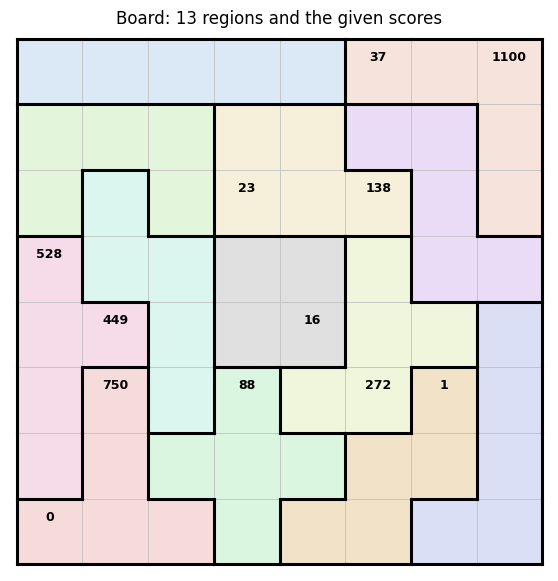

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_board(ax, towers=None, path=None, scores=None, title=""):
    palette = {'A':'#dbe9f6','B':'#f6e3db','C':'#e3f6db','D':'#f6f0db','E':'#eadbf6',
               'F':'#dbf6ef','G':'#f6dbe9','H':'#e0e0e0','I':'#f0f6db','J':'#dbdff6',
               'K':'#f6dbdb','L':'#dbf6e0','M':'#f2e2c8'}
    for r in range(8):
        for c in range(8):
            ax.add_patch(mpatches.Rectangle((c, 7-r), 1, 1,
                         facecolor=palette[region[(r,c)]], edgecolor='0.75', lw=0.5))
    # bold region borders
    for r in range(8):
        for c in range(8):
            if c == 7 or region[(r,c)] != region[(r,c+1)]:
                ax.plot([c+1,c+1],[7-r,8-r],'k',lw=2.2)
            if c == 0:
                ax.plot([0,0],[7-r,8-r],'k',lw=2.2)
            if r == 7 or region[(r,c)] != region[(r+1,c)]:
                ax.plot([c,c+1],[7-r,7-r],'k',lw=2.2)
            if r == 0:
                ax.plot([c,c+1],[8,8],'k',lw=2.2)
    if towers:
        for (r,c) in towers:
            ax.add_patch(mpatches.Rectangle((c+0.08, 7-r+0.08), 0.84, 0.84,
                         fill=False, edgecolor='darkorange', lw=2.5))
    for (r,c),v in NUM.items():
        ax.text(c+0.5, 7-r+0.72, str(v), ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(START[1]+0.5, 7-START[0]+0.72, "0", ha='center', va='center', fontsize=9, fontweight='bold')
    if path:
        xs = [c+0.5 for r,c in path]; ys = [7-r+0.42 for r,c in path]
        ax.plot(xs, ys, '-', color='seagreen', lw=1.6, alpha=0.8, zorder=3)
        ax.plot(xs[0], ys[0], 'o', color='seagreen', ms=9, zorder=4)
        ax.plot(xs[-1], ys[-1], 's', color='crimson', ms=9, zorder=4)
    if scores:
        for (r,c),s in scores.items():
            ax.text(c+0.5, 7-r+0.30, str(s), ha='center', va='center', fontsize=7.5, color='#333')
    ax.set_xlim(-0.1, 8.1); ax.set_ylim(-0.1, 8.1)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title)

fig, ax = plt.subplots(figsize=(7,7))
draw_board(ax, title="Board: 13 regions and the given scores")
plt.show()

## 2. The score math does most of the work

Here's the trick: forget the board for a second and just track `(score, height)`. On move N you can do `+N` (height stays the same), `×N` (only from height 1, ends at height 2), or `÷N` (only from height 2 when it divides evenly, ends at height 1). One thing that falls out for free: you can never do two `×` in a row or two `÷` in a row.

Now, the score at move 3 has to be one of the numbers on the grid. If you list every possible score after 3 moves, they're all tiny — and the only grid number in that list is **1**. And there's exactly one way to get 1: `+1, +2, ÷3`. That alone is huge. The ÷3 means the knight was standing at height 2 on move 2, and since the two moves before it were flat, the height traces all the way back to the start — so the starting square is a tower, and so are the first two squares it lands on.

Keep playing that same game forward and every checkpoint up to move 18 gets locked in:

In [3]:
CAP = 10**9

def reach(states, t0, t1):
    """All (score, altitude) states reachable from `states` at time t0, after moves t0+1..t1."""
    for N in range(t0+1, t1+1):
        nxt = set()
        for v, h in states:
            nxt.add((v+N, h))
            if h == 1 and v*N <= CAP: nxt.add((v*N, 2))
            if h == 2 and v % N == 0: nxt.add((v//N, 1))
        states = nxt
    return states

def op_paths(s, h, t0, t1, goal):
    """All op sequences from (s,h) at t0 hitting score `goal` at t1."""
    out = []
    def rec(v, hh, N, ops):
        if N > t1:
            if v == goal: out.append((ops, hh))
            return
        if v+N <= CAP: rec(v+N, hh, N+1, ops+[f'+{N}'])
        if hh == 1 and v*N <= CAP: rec(v*N, 2, N+1, ops+[f'*{N}'])
        if hh == 2 and v % N == 0: rec(v//N, 1, N+1, ops+[f'/{N}'])
    rec(s, h, t0+1, [])
    return out

VALS = set(NUM.values())
states = {(0,1), (0,2)}   # start altitude unknown
t, used = 0, []
for cp in [3, 6, 9, 12, 15, 18]:
    states = reach(states, t, cp)
    hits = sorted({v for v, h in states if v in VALS and v not in used})
    assert len(hits) == 1, hits
    v = hits[0]; used.append(v)
    states = {(vv, hh) for vv, hh in states if vv == v}
    print(f"move {cp:2d}: forced checkpoint value = {v:4d}   at square {[k for k,x in NUM.items() if x==v][0]}")
    t = cp
print("\nEarly checkpoints fully forced:", used)

move  3: forced checkpoint value =    1   at square (5, 6)
move  6: forced checkpoint value =   16   at square (4, 4)
move  9: forced checkpoint value =   23   at square (2, 3)
move 12: forced checkpoint value =  528   at square (3, 0)
move 15: forced checkpoint value =   37   at square (0, 5)
move 18: forced checkpoint value =   88   at square (5, 3)

Early checkpoints fully forced: [1, 16, 23, 528, 37, 88]


So moves 3 through 18 hit **1, 16, 23, 528, 37, 88** in that exact order, each at its own labeled square. (Fun one: 528 comes from a `×12`, meaning the knight lands *on* a tower there — the numbered square (3,0) is itself the Y-pentomino's tower.)

### Figuring out K

At move 18 the score is 88. The next checkpoint is K moves later and has to be one of the five remaining numbers {138, 272, 449, 750, 1100}. So: for each K, which of those can you actually reach?

In [4]:
LATE = {138, 272, 449, 750, 1100}
for K in range(4, 10):
    hits = sorted({v for v, h in reach({(88,1)}, 18, 18+K) if v in LATE})
    print(f"K = {K}: reachable late checkpoint values -> {hits}")

K = 4: reachable late checkpoint values -> []
K = 5: reachable late checkpoint values -> []
K = 6: reachable late checkpoint values -> []
K = 7: reachable late checkpoint values -> [138]
K = 8: reachable late checkpoint values -> []
K = 9: reachable late checkpoint values -> []


In [5]:
# K = 7 is the only survivor. Chain all five late checkpoints:
import itertools
K = 7
for order in itertools.permutations(sorted(LATE)):
    states, t, ok = {(88,1)}, 18, True
    for goal in order:
        states = {(v,h) for v,h in reach(states, t, t+K) if v == goal}
        t += K
        if not states: ok = False; break
    if ok:
        print("Only feasible order:", order)
        forced_order = order

print()
print("Unique op sequence per segment:")
s, h, t = 88, 1, 18
for goal in forced_order:
    paths = op_paths(s, h, t, t+K, goal)
    assert len(paths) == 1
    ops, hend = paths[0]
    print(f"  moves {t+1}-{t+K}: {ops}  ->  {goal}")
    s, h, t = goal, hend, t+K

Only feasible order: (138, 272, 449, 750, 1100)

Unique op sequence per segment:
  moves 19-25: ['+19', '+20', '*21', '+22', '+23', '/24', '+25']  ->  138
  moves 26-32: ['+26', '+27', '+28', '+29', '*30', '/31', '+32']  ->  272
  moves 33-39: ['*33', '/34', '+35', '+36', '+37', '+38', '+39']  ->  449
  moves 40-46: ['+40', '+41', '+42', '+43', '+44', '+45', '+46']  ->  750
  moves 47-53: ['+47', '+48', '+49', '+50', '+51', '+52', '+53']  ->  1100


## 3. The actual search

Everything above ignored the board — it only proves what the scores *must* do, not that a knight can actually pull it off. So this part is a move-by-move search over the real board. The main ideas:

- **towers get decided on the fly**: whenever the knight lands at height 2, that square becomes its region's tower (max one per region); if a region gets fully visited with no tower, that branch is dead
- **checkpoints are strict**: on a checkpoint move the knight has to land on an unused numbered square whose value equals the new score; on every other move, numbered squares are off-limits (a number could only have been written on a checkpoint)
- **quick math check**: at any point, if no remaining grid number is even reachable score-wise by the next checkpoint, bail (memoized so it's cheap)
- **distance check**: each move covers at most 2 squares in any direction, so if every candidate checkpoint square is too far away, bail
- **the ending**: the trip ends the instant the 13th tower is stepped on, which has to happen somewhere between move 18+5K and 18+6K−1

I run it for every K from 4 to 9 — not just 7 — so at the end I know the answer is the *only* one, no assumptions.

In [6]:
import sys
sys.setrecursionlimit(100000)

solutions = []

def solve_for_K(K):
    cps = [3,6,9,12,15,18] + [18 + i*K for i in range(1, 6)]
    cpset = set(cps)
    Lmin, Lmax = 18 + 5*K, 18 + 6*K - 1
    VALS_ = sorted(NUM.values())
    SQ_OF_VAL = {v: k for k, v in NUM.items()}
    feas_memo = {}

    def next_cp(t):
        for c in cps:
            if c > t: return c
        return None

    def feas(t, score, h, used_fs):
        nc = next_cp(t)
        if nc is None: return True
        key = (t, score, h, used_fs)
        if key in feas_memo: return feas_memo[key]
        ok, N = False, t + 1
        if score <= CAP:
            targets = [v for v in VALS_ if v not in used_fs]
            def arrive(s2, h2):
                return (s2 in targets) if N == nc else feas(N, s2, h2, used_fs)
            if arrive(score + N, h): ok = True
            if not ok and h == 1 and score*N <= CAP and arrive(score*N, 2): ok = True
            if not ok and h == 2 and score % N == 0 and arrive(score//N, 1): ok = True
        feas_memo[key] = ok
        return ok

    heights, towers, used = {}, {}, set()
    path, scores = [START], [0]
    visited = {START}

    def dfs(t, pos, score):
        if len(towers) == 13:
            if Lmin <= t <= Lmax:
                solutions.append((K, list(path), list(scores), dict(towers)))
            return
        if t >= Lmax or 13 - len(towers) > Lmax - t:
            return
        N, h = t + 1, heights[pos]
        is_cp = N in cpset
        nc = next_cp(t)
        if nc is not None:
            rem = nc - t
            cands = [SQ_OF_VAL[v] for v in VALS_ if v not in used]
            if not any(max(abs(pos[0]-q[0]), abs(pos[1]-q[1])) <= 2*rem for q in cands):
                return

        def try_move(dst, mtype, s2):
            g = region[dst]
            newtower = (mtype == 'up') or (mtype == 'level' and h == 2)
            if newtower:
                if g in towers: return
                towers[g] = dst
                h2 = 2
            else:
                h2 = 1
            ok = (dst in NUM and NUM[dst] == s2 and NUM[dst] not in used) if is_cp else (dst not in NUM)
            if ok:
                visited.add(dst); heights[dst] = h2
                dead = g not in towers and all(p in visited for p in cells_of[g])
                if not dead:
                    if is_cp: used.add(NUM[dst])
                    path.append(dst); scores.append(s2)
                    if len(towers) == 13 or feas(N, s2, h2, frozenset(used)):
                        dfs(N, dst, s2)
                    path.pop(); scores.pop()
                    if is_cp: used.discard(NUM[dst])
                visited.discard(dst); heights.pop(dst)
            if newtower: del towers[g]

        for d in KNIGHT:
            dst = (pos[0]+d[0], pos[1]+d[1])
            if inb(dst) and dst not in visited: try_move(dst, 'level', score + N)
        if h == 1 and score*N <= CAP:
            for d in UPDOWN:
                dst = (pos[0]+d[0], pos[1]+d[1])
                if inb(dst) and dst not in visited: try_move(dst, 'up', score*N)
        if h == 2 and score % N == 0:
            for d in UPDOWN:
                dst = (pos[0]+d[0], pos[1]+d[1])
                if inb(dst) and dst not in visited: try_move(dst, 'down', score//N)

    for h0 in (1, 2):
        heights.clear(); towers.clear(); used.clear()
        visited.clear(); visited.add(START)
        heights[START] = h0
        if h0 == 2: towers[region[START]] = START
        path[:] = [START]; scores[:] = [0]
        dfs(0, START, 0)

for K in range(4, 10):
    solve_for_K(K)
    print(f"K = {K}: cumulative solutions = {len(solutions)}")

assert len(solutions) == 1, "solution should be unique"
K, path, scores, towers = solutions[0]
print(f"\nUNIQUE solution: K = {K}, path length = {len(path)-1} moves, ends at {path[-1]}")

K = 4: cumulative solutions = 0
K = 5: cumulative solutions = 0
K = 6: cumulative solutions = 0


K = 7: cumulative solutions = 1
K = 8: cumulative solutions = 1
K = 9: cumulative solutions = 1

UNIQUE solution: K = 7, path length = 54 moves, ends at (2, 7)


## 4. Checking everything from scratch

I don't trust my own solver blindly, so this cell re-verifies the whole path against the raw rules: every move is a legal 3D knight move, the score recurrence works out, every down-move divides cleanly, checkpoints land where they should, no square is visited twice, each region has exactly one tower and it got visited, and the trip stops exactly on the 13th tower.

In [7]:
tower_set = set(towers.values())
h = lambda p: 2 if p in tower_set else 1

assert len(path) == len(set(path)), "revisited a square"
s = 0
recomputed = [0]
for i in range(1, len(path)):
    a, b = path[i-1], path[i]
    d = sorted([abs(a[0]-b[0]), abs(a[1]-b[1]), abs(h(a)-h(b))])
    assert d == [0, 1, 2], f"illegal move {i}: {a} -> {b}"
    if h(a) == h(b):   s += i
    elif h(b) > h(a):  s *= i
    else:
        assert s % i == 0, f"illegal down at move {i}"
        s //= i
    recomputed.append(s)
assert recomputed == scores

cps = [3,6,9,12,15,18] + [18 + i*K for i in range(1, 6)]
for t in cps:
    assert path[t] in NUM and NUM[path[t]] == scores[t]
for i, p in enumerate(path):
    if p in NUM: assert i in cps, "numbered square visited off-checkpoint"

regs = {}
for p in tower_set: regs.setdefault(region[p], []).append(p)
assert sorted(regs) == sorted(cells_of) and all(len(v) == 1 for v in regs.values())
assert tower_set <= set(path), "an unvisited tower"
assert path[-1] in tower_set and path[-1] not in path[:-1], "must stop on the 13th tower"

print("All checks pass.")
print("Towers (region -> square):", dict(sorted(towers.items())))
print("\nMove-by-move:")
for i, (p, sc) in enumerate(zip(path, scores)):
    tag = "  <- checkpoint" if i in cps else (" (start)" if i == 0 else "")
    tw = "  [tower]" if p in tower_set else ""
    print(f"  move {i:2d}: {p}  score {sc}{tw}{tag}")

All checks pass.
Towers (region -> square): {'A': (0, 3), 'B': (2, 7), 'C': (1, 1), 'D': (2, 4), 'E': (1, 5), 'F': (4, 2), 'G': (3, 0), 'H': (3, 4), 'I': (5, 4), 'J': (5, 7), 'K': (7, 0), 'L': (6, 2), 'M': (7, 4)}

Move-by-move:
  move  0: (7, 0)  score 0  [tower] (start)
  move  1: (6, 2)  score 1  [tower]
  move  2: (5, 4)  score 3  [tower]
  move  3: (5, 6)  score 1  <- checkpoint
  move  4: (7, 7)  score 5
  move  5: (6, 5)  score 10
  move  6: (4, 4)  score 16  <- checkpoint
  move  7: (2, 4)  score 112  [tower]
  move  8: (0, 4)  score 14
  move  9: (2, 3)  score 23  <- checkpoint
  move 10: (0, 2)  score 33
  move 11: (1, 0)  score 44
  move 12: (3, 0)  score 528  [tower]  <- checkpoint
  move 13: (1, 1)  score 541  [tower]
  move 14: (0, 3)  score 555  [tower]
  move 15: (0, 5)  score 37  <- checkpoint
  move 16: (1, 3)  score 53
  move 17: (3, 2)  score 70
  move 18: (5, 3)  score 88  <- checkpoint
  move 19: (6, 1)  score 107
  move 20: (4, 0)  score 127
  move 21: (4, 2)  sc

## 5. The answer

Every visited square gets the score the knight had when it arrived there (the last square gets 1100 × 54 = 59,400 — never written down since the trip ended right there). Then for each of the 9 squares the knight never touched, I add up the scores of its visited neighbors, and sum those totals.

In [8]:
sc = {p: s for p, s in zip(path, scores)}
visited = set(path)
total = 0
print("Unvisited squares and their neighbor sums:")
for r in range(8):
    for c in range(8):
        if (r, c) not in visited:
            ns = sum(sc[q] for q in [(r-1,c),(r+1,c),(r,c-1),(r,c+1)] if q in sc)
            total += ns
            print(f"  {(r,c)} -> {ns}")
print(f"\nANSWER: {total}")
assert total == 33609

Unvisited squares and their neighbor sums:
  (0, 0) -> 44
  (0, 1) -> 574
  (0, 6) -> 1436
  (2, 1) -> 2012
  (3, 6) -> 1646
  (4, 6) -> 1890
  (6, 7) -> 9925
  (7, 3) -> 8392
  (7, 5) -> 7690

ANSWER: 33609


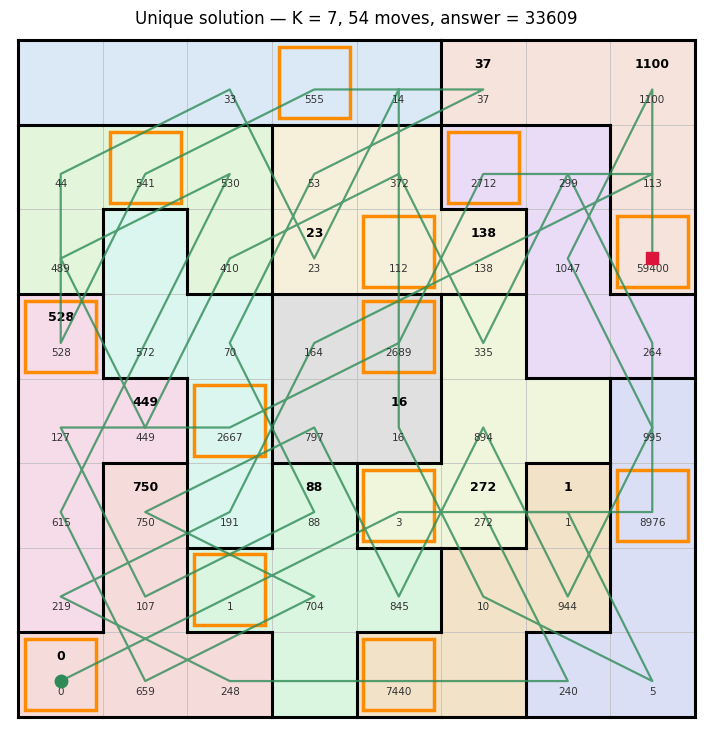

In [9]:
fig, ax = plt.subplots(figsize=(9,9))
draw_board(ax, towers=tower_set, path=path, scores=sc,
           title=f"Unique solution — K = {K}, {len(path)-1} moves, answer = {total}")
plt.show()

## Wrapping up

- The score math alone forces the six early checkpoints (**1, 16, 23, 528, 37, 88**), forces **K = 7**, forces the order of the late checkpoints (**138, 272, 449, 750, 1100** at moves 25, 32, 39, 46, 53), and even forces the type of every single one of the 53 scored moves.
- Once you add the board back in, exactly **one** path survives: 54 moves, starting on the T-pentomino's tower at (7,0) and ending the moment the knight climbs onto the 13th tower — the V-pentomino's, at (2,7) — with a final unwritten score of 59,400.
- Adding up the neighbor sums over the 9 untouched squares:

$$\boxed{33609}$$